# EfficientNet-B0 训练测试

In [10]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score, confusion_matrix
import timm
from tqdm import tqdm
import numpy as np
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 参数配置
# ===========================
BATCH_SIZE = 64
NUM_CLASSES = 8
EPOCHS = 30
LR = 1e-4
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Galaxy-Classification-Using-CNN/output_dataset'
LOCAL_MODEL_PATH = '/mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Effficient/efficientnet_b0/pytorch_model.bin'
SAVE_PATH = 'best_efficientnet_b0.pth'
REPORT_DIR = 'efficientnet_b0_reports'  # 报告保存目录

# 早停和学习率调度参数
PATIENCE_EARLY_STOP = 7  # 早停耐心值
PATIENCE_LR = 3  # 学习率调度耐心值

print(f"Using device: {DEVICE}")

# ===========================
# 数据增强与加载
# ===========================
# 训练集数据增强
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])  # ImageNet标准化
])

# 验证集和测试集不做数据增强，只做标准化
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

train_set = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_set = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=val_test_transform)
test_set = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=val_test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_set)}, Val samples: {len(val_set)}, Test samples: {len(test_set)}")
print(f"Classes: {train_set.classes}")

# ===========================
# 模型构建并加载本地权重
# ===========================
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)

# 加载本地的 pytorch_model.bin 权重
if os.path.exists(LOCAL_MODEL_PATH):
    print(f"Loading local weights from {LOCAL_MODEL_PATH}...")
    state_dict = torch.load(LOCAL_MODEL_PATH, map_location=DEVICE)
    
    # 如果本地模型包含了原来的分类头（1000类），忽略它
    keys_to_remove = []
    for key in state_dict.keys():
        if 'classifier' in key or 'head' in key or 'fc' in key:
            keys_to_remove.append(key)
    
    for key in keys_to_remove:
        del state_dict[key]
    
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"✅ Loaded pretrained weights")
    print(f"   Missing keys: {len(missing)} (expected for classifier layer)")
    print(f"   Unexpected keys: {len(unexpected)}")
    
    if len(missing) > 10:  # 如果缺失的键太多，可能有问题
        print(f"⚠️  Warning: Many missing keys. First 5: {missing[:5]}")
else:
    print(f"⚠️  Local weights not found at {LOCAL_MODEL_PATH}, using random initialization")

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# 学习率调度器：验证集准确率不提升时降低学习率
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=PATIENCE_LR, verbose=True
)

# ===========================
# 验证函数
# ===========================
def validate():
    model.eval()
    correct = 0
    total_loss = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            correct += (outputs.argmax(1) == targets).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / len(val_set)
    
    return accuracy, avg_loss

# ===========================
# 绘制混淆矩阵函数
# ===========================
def plot_confusion_matrix(y_true, y_pred, class_names, save_path):
    """
    绘制并保存混淆矩阵
    
    Args:
        y_true: 真实标签
        y_pred: 预测标签
        class_names: 类别名称列表
        save_path: 保存路径
    """
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    
    # 创建两个子图：原始计数和归一化百分比
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 子图1: 原始计数
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # 子图2: 归一化百分比（按行归一化）
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Percentage'})
    axes[1].set_title('Confusion Matrix (Normalized by True Label)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Confusion matrix saved to: {save_path}")
    plt.close()
    
    return cm

# ===========================
# 训练函数（保存最优模型 + 早停）
# ===========================
def train():
    best_val_acc = 0
    no_improve_epochs = 0
    train_history = []
    val_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        total_correct = 0

        progress_bar = tqdm(train_loader, desc=f"[Epoch {epoch+1}/{EPOCHS}] Training")
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_correct += (outputs.argmax(1) == targets).sum().item()
            
            # 更新进度条
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_acc = total_correct / len(train_set)
        train_loss = total_loss / len(train_loader)
        val_acc, val_loss = validate()
        
        # 记录历史
        train_history.append({'epoch': epoch+1, 'loss': train_loss, 'acc': train_acc})
        val_history.append({'epoch': epoch+1, 'loss': val_loss, 'acc': val_acc})
        
        # 学习率调度
        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch+1}/{EPOCHS}:")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        print(f"  LR: {current_lr:.6f}")

        # 保存验证集上表现最好的模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_epochs = 0
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'train_history': train_history,
                'val_history': val_history
            }, SAVE_PATH)
            print(f"  ✅ Saved best model! Val Acc: {val_acc:.4f}")
        else:
            no_improve_epochs += 1
            print(f"  No improvement for {no_improve_epochs} epoch(s)")
        
        # 早停
        if no_improve_epochs >= PATIENCE_EARLY_STOP:
            print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
            print(f"   Best validation accuracy: {best_val_acc:.4f}")
            break
        
        print("-" * 70)
    
    print(f"\n{'='*70}")
    print(f"Training completed! Best Val Acc: {best_val_acc:.4f}")
    print(f"{'='*70}\n")
    
    return train_history, val_history

# ===========================
# 测试函数（详细分类指标）
# ===========================
def test():
    print("Loading best model for testing...")
    checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with val acc {checkpoint['best_val_acc']:.4f}")
    
    model.eval()

    y_true, y_pred = [], []
    correct = 0
    
    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc="[Testing]"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu()
            
            y_true.extend(targets.numpy())
            y_pred.extend(preds.numpy())
            correct += (preds == targets).sum().item()
    
    # 计算准确率
    test_acc = accuracy_score(y_true, y_pred)
    
    # 获取类别名称
    target_names = train_set.classes
    
    # 计算macro平均指标
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    
    # 计算weighted平均指标
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # 计算每个类别的指标
    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    # 生成详细分类报告（字符串格式）
    report_str = classification_report(y_true, y_pred, target_names=target_names, digits=4)
    
    # 绘制并保存混淆矩阵
    timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    os.makedirs(REPORT_DIR, exist_ok=True)
    cm_save_path = os.path.join(REPORT_DIR, f'confusion_matrix_{timestamp_str}.png')
    cm = plot_confusion_matrix(y_true, y_pred, target_names, cm_save_path)
    
    # 打印结果到控制台
    print("\n" + "="*80)
    print("================ Galaxy Classification Performance Report ================")
    print("="*80)
    print(f"\n【Overall Accuracy】")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"\n{'='*80}")
    
    print(f"\n【Macro Average】(unweighted mean of all classes)")
    print(f"  Macro Precision:  {macro_precision:.4f}")
    print(f"  Macro Recall:     {macro_recall:.4f}")
    print(f"  Macro F1-Score:   {macro_f1:.4f}")
    
    print(f"\n{'='*80}")
    print(f"\n【Weighted Average】(weighted by support)")
    print(f"  Weighted Precision:  {weighted_precision:.4f}")
    print(f"  Weighted Recall:     {weighted_recall:.4f}")
    print(f"  Weighted F1-Score:   {weighted_f1:.4f}")
    
    print(f"\n{'='*80}")
    print(f"\n【Per-Class Performance】")
    print(report_str)
    print("="*80)
    
    # 构建结果字典
    results = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model': 'EfficientNet-B0',
        'best_epoch': int(checkpoint['epoch']),
        'best_val_acc': float(checkpoint['best_val_acc']),
        'overall': {
            'accuracy': float(test_acc)
        },
        'macro_average': {
            'precision': float(macro_precision),
            'recall': float(macro_recall),
            'f1_score': float(macro_f1)
        },
        'weighted_average': {
            'precision': float(weighted_precision),
            'recall': float(weighted_recall),
            'f1_score': float(weighted_f1)
        },
        'per_class': {},
        'confusion_matrix': cm.tolist()  # 添加混淆矩阵到结果中
    }
    
    # 添加每个类别的详细指标
    for i, class_name in enumerate(target_names):
        results['per_class'][class_name] = {
            'precision': float(per_class_precision[i]),
            'recall': float(per_class_recall[i]),
            'f1_score': float(per_class_f1[i]),
            'support': int(per_class_support[i])
        }
    
    # 保存JSON格式报告
    json_report_path = os.path.join(REPORT_DIR, f'test_report_{timestamp_str}.json')
    with open(json_report_path, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=4, ensure_ascii=False)
    print(f"\n✅ JSON report saved to: {json_report_path}")
    
    # 保存文本格式报告
    txt_report_path = os.path.join(REPORT_DIR, f'test_report_{timestamp_str}.txt')
    with open(txt_report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("Galaxy Classification Performance Report - EfficientNet-B0\n")
        f.write("="*80 + "\n")
        f.write(f"\nGenerated at: {results['timestamp']}\n")
        f.write(f"Best Epoch: {results['best_epoch']}\n")
        f.write(f"Best Validation Accuracy: {results['best_val_acc']:.4f}\n")
        f.write("\n" + "="*80 + "\n")
        
        f.write(f"\n【Overall Accuracy】\n")
        f.write(f"  Test Accuracy: {test_acc:.4f}\n")
        f.write(f"\n{'='*80}\n")
        
        f.write(f"\n【Macro Average】(unweighted mean of all classes)\n")
        f.write(f"  Macro Precision:  {macro_precision:.4f}\n")
        f.write(f"  Macro Recall:     {macro_recall:.4f}\n")
        f.write(f"  Macro F1-Score:   {macro_f1:.4f}\n")
        
        f.write(f"\n{'='*80}\n")
        f.write(f"\n【Weighted Average】(weighted by support)\n")
        f.write(f"  Weighted Precision:  {weighted_precision:.4f}\n")
        f.write(f"  Weighted Recall:     {weighted_recall:.4f}\n")
        f.write(f"  Weighted F1-Score:   {weighted_f1:.4f}\n")
        
        f.write(f"\n{'='*80}\n")
        f.write(f"\n【Per-Class Performance】\n")
        f.write(report_str)
        f.write("\n" + "="*80 + "\n")
        
        # 添加每个类别的详细数据
        f.write("\n【Detailed Per-Class Metrics】\n")
        f.write("-" * 80 + "\n")
        for class_name, metrics in results['per_class'].items():
            f.write(f"\n{class_name}:\n")
            f.write(f"  Precision: {metrics['precision']:.4f}\n")
            f.write(f"  Recall:    {metrics['recall']:.4f}\n")
            f.write(f"  F1-Score:  {metrics['f1_score']:.4f}\n")
            f.write(f"  Support:   {metrics['support']}\n")
        
        # 添加混淆矩阵
        f.write("\n" + "="*80 + "\n")
        f.write("\n【Confusion Matrix】\n")
        f.write("-" * 80 + "\n")
        f.write(f"Confusion matrix visualization saved to: confusion_matrix_{timestamp_str}.png\n")
        f.write("\nConfusion Matrix (Counts):\n")
        f.write("Rows: True Labels, Columns: Predicted Labels\n\n")
        
        # 打印表头
        f.write("True\\Pred   ")
        for name in target_names:
            f.write(f"{name[:8]:>10s}")
        f.write("\n")
        f.write("-" * (12 + 10 * len(target_names)) + "\n")
        
        # 打印混淆矩阵内容
        for i, true_name in enumerate(target_names):
            f.write(f"{true_name[:10]:<12s}")
            for j in range(len(target_names)):
                f.write(f"{cm[i][j]:>10d}")
            f.write("\n")
        
        f.write("\n" + "="*80 + "\n")
    
    print(f"✅ Text report saved to: {txt_report_path}")
    
    return results

# ===========================
# 主程序
# ===========================
if __name__ == "__main__":
    print("="*70)
    print("Starting EfficientNet-B0 Training for Galaxy Classification")
    print("="*70)
    
    # 训练
    train_history, val_history = train()
    
    # 测试
    results = test()
    
    print("\n✅ All done!")
    print(f"\n【Final Test Results Summary】")
    print(f"  Accuracy:         {results['overall']['accuracy']:.4f}")
    print(f"  Macro F1:         {results['macro_average']['f1_score']:.4f}")
    print(f"  Weighted F1:      {results['weighted_average']['f1_score']:.4f}")
    print(f"\nReports saved in '{REPORT_DIR}/' directory")

Using device: cuda:1
Train samples: 43796, Val samples: 554, Test samples: 11090
Classes: ['barred_spirals', 'cigar_shaped_elliptical', 'edge_on', 'in_between_elliptical', 'irregular', 'merger', 'round_elliptical', 'unbarred_spirals']
Loading local weights from /mnt/acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/Modern CNNs/Effficient/efficientnet_b0/pytorch_model.bin...


/tmp/ipykernel_4089263/2392836709.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(LOCAL_MODEL_PATH, map_location=DEVICE)


✅ Loaded pretrained weights
   Missing keys: 3 (expected for classifier layer)
   Unexpected keys: 0
Starting EfficientNet-B0 Training for Galaxy Classification


[Epoch 1/30] Training: 100%|██████████| 685/685 [00:47<00:00, 14.34it/s, loss=0.7108]


Epoch 1/30:
  Train - Loss: 1.4010, Acc: 0.5363
  Val   - Loss: 0.9959, Acc: 0.6588
  LR: 0.000100
  ✅ Saved best model! Val Acc: 0.6588
----------------------------------------------------------------------


...

Epoch 17/30:
  Train - Loss: 0.2889, Acc: 0.8926
  Val   - Loss: 0.7363, Acc: 0.7708
  LR: 0.000050
  No improvement for 6 epoch(s)
----------------------------------------------------------------------


[Epoch 18/30] Training: 100%|██████████| 685/685 [00:47<00:00, 14.41it/s, loss=0.2840]
/tmp/ipykernel_4089263/2392836709.py:259: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Epoch 18/30:
  Train - Loss: 0.2711, Acc: 0.8985
  Val   - Loss: 0.7109, Acc: 0.7798
  LR: 0.000050
  No improvement for 7 epoch(s)

🛑 Early stopping triggered after 18 epochs
   Best validation accuracy: 0.7978

Training completed! Best Val Acc: 0.7978

Loading best model for testing...
Loaded model from epoch 11 with val acc 0.7978


[Testing]: 100%|██████████| 174/174 [00:48<00:00,  3.62it/s]


✅ Confusion matrix saved to: efficientnet_b0_reports/confusion_matrix_20260131_172204.png

================ Galaxy Classification Performance Report ================

【Overall Accuracy】
  Test Accuracy: 0.7771


【Macro Average】(unweighted mean of all classes)
  Macro Precision:  0.7689
  Macro Recall:     0.7719
  Macro F1-Score:   0.7673


【Weighted Average】(weighted by support)
  Weighted Precision:  0.7797
  Weighted Recall:     0.7771
  Weighted F1-Score:   0.7751


【Per-Class Performance】
                         precision    recall  f1-score   support

         barred_spirals     0.8590    0.7994    0.8281      1600
cigar_shaped_elliptical     0.7923    0.8024    0.7973      1483
                edge_on     0.8107    0.8675    0.8382      1600
  in_between_elliptical     0.8398    0.6881    0.7564      1600
              irregular     0.6939    0.6442    0.6681      1186
                 merger     0.6910    0.7648    0.7260       421
       round_elliptical     0.7417    0.9350 

In [4]:
import sys
sys.executable

'/miniconda3/envs/python38/bin/python'

In [5]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.6/857.6 MB 2.6 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 11.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 13.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.6 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.5 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 10.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
import sys
!{sys.executable} -m pip install timm

  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 6.6 MB/s eta 0:00:0000:0100:01
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 31.7 MB/s eta 0:00:00
Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)


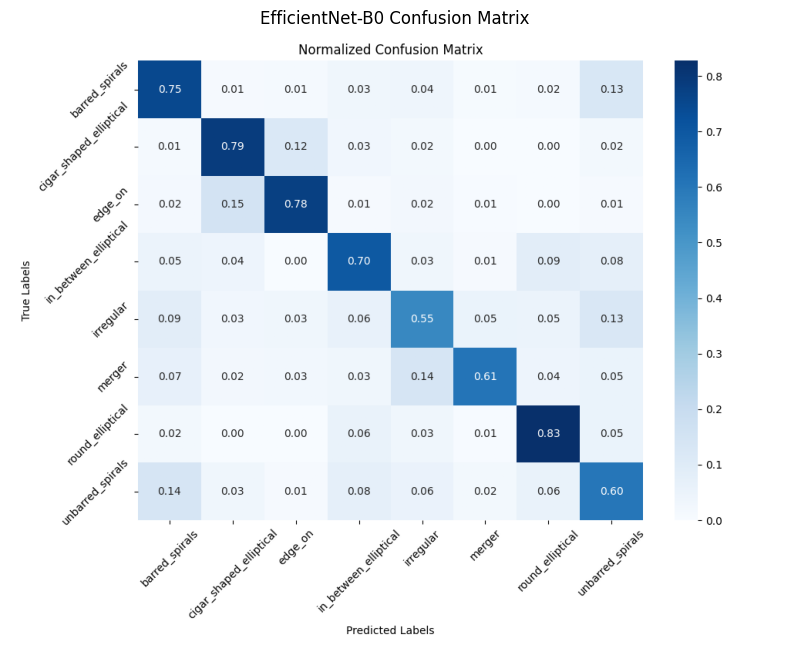

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 加载图片
img_path = '/remote-home/cs_acmis_hby/Galaxy-Zoo-Classification/Contrast_experiment/baseline_result/EfficientNet-B0_confusion_matrix.png'
img = mpimg.imread(img_path)

# 显示图片
plt.figure(figsize=(10, 8))  # 调整图片大小
plt.imshow(img)
plt.axis('off')  # 不显示坐标轴
plt.title('EfficientNet-B0 Confusion Matrix', fontsize=12)
plt.show()